In [ ]:
X =
[[1, 2, 1, 0, 0],
 [0, 1, 2, 1, 0],
 [1, 0, 2, 2, 1],
 [0, 1, 1, 2, 0],
 [1, 2, 0, 1, 1]]




In [ ]:
Initial Layer 

W =
[[ 0.1,  0.2, -0.1],
 [ 0.0,  0.1,  0.2],
 [-0.1,  0.0,  0.1]]


In [ ]:
Assume Gradients from output

dL_dout=
[[ 1.0, -1.0, 0.5],
 [ 0.0,  0.5, -0.5],
 [-1.0,  1.0, -0.5]]


This simulates how much each output pixel contributed to the loss — what backprop sends to this layer.    

In [ ]:
Computed Gradient

grads_W =
[[-3.0,  2.5,  1.0],
 [-0.5, -1.5,  2.5],
 [ 3.0, -4.0,  2.0]]


These values are accumulated over all the positions where the filter was applied (sliding over the input).

In [ ]:
| Patch Position | Patch Top-Left (X\[i,j]) | Gradient (δ) | Contribution = δ × X\[i,j] |
| -------------- | ------------------------ | ------------ | -------------------------- |
| (0, 0)         | 1                        | 1.0          | 1.0                        |
| (0, 1)         | 2                        | -1.0         | -2.0                       |
| (0, 2)         | 1                        | 0.5          | 0.5                        |
| (1, 0)         | 0                        | 0.0          | 0.0                        |
| (1, 1)         | 1                        | 0.5          | 0.5                        |
| (1, 2)         | 2                        | -0.5         | -1.0                       |
| (2, 0)         | 1                        | -1.0         | -1.0                       |
| (2, 1)         | 0                        | 1.0          | 0.0                        |
| (2, 2)         | 2                        | -0.5         | -1.0                       |


W[0,0]:
1.0−2.0+0.5+0.0+0.5−1.0−1.0+0.0−1.0=−3.0

In [ ]:
Updated Filter Weights (After Backprop Update, LR=0.01)


W_updated =
[[ 0.130,  0.175, -0.110],
 [ 0.005,  0.115,  0.175],
 [-0.130,  0.040,  0.080]]

Wnew​=W−η⋅∂W∂L​


Wnew​[0,0]
=0.1−(0.01⋅−3.0)
=0.1+0.03=0.13


In [1]:
import numpy as np

# Input image: 3 channels, each 5x5
X = np.stack([
    np.array([[1, 2, 1, 0, 0],
              [0, 1, 2, 1, 0],
              [1, 0, 2, 2, 1],
              [0, 1, 1, 2, 0],
              [1, 2, 0, 1, 1]]),
    np.array([[0, 1, 1, 0, 0],
              [1, 0, 1, 0, 1],
              [0, 1, 0, 1, 0],
              [1, 1, 0, 1, 1],
              [0, 1, 1, 0, 1]]),
    np.array([[1, 0, 0, 0, 1],
              [0, 1, 0, 1, 0],
              [1, 1, 0, 1, 1],
              [0, 0, 1, 0, 0],
              [1, 1, 1, 0, 0]])
])

# Simulated gradient from next layer
dL_dout = np.array([
    [1.0, -1.0,  0.5],
    [0.0,  0.5, -0.5],
    [-1.0, 1.0, -0.5]
])

# Accumulate ∂L/∂W[1,1] for all filter applications
C, H, W = X.shape
accumulated = np.zeros((C,))
print("Step-by-step accumulation of ∂L/∂W[1,1] across all positions:\n")

for step, (i, j) in enumerate([(i, j) for i in range(H - 2) for j in range(W - 2)]):
    center_pixel = X[:, i+1, j+1]    # (i+1, j+1) is the center of the 3x3 patch
    delta = dL_dout[i, j]            # Gradient from output
    contrib = delta * center_pixel   # Per-channel contribution
    accumulated += contrib

    print(f"Step {step+1}: Center @ X[:, {i+1}, {j+1}]")
    print(f"  δ = {delta}")
    print(f"  Input Center Pixels = {center_pixel}")
    print(f"  Contribution = δ * pixel = {np.round(contrib, 2)}")
    print(f"  Accumulated ∂L/∂W[1,1] so far = {np.round(accumulated, 2)}\n")

print("✅ Final accumulated ∂L/∂W[1,1] per channel:", np.round(accumulated, 2))


Step-by-step accumulation of ∂L/∂W[1,1] across all positions:

Step 1: Center @ X[:, 1, 1]
  δ = 1.0
  Input Center Pixels = [1 0 1]
  Contribution = δ * pixel = [1. 0. 1.]
  Accumulated ∂L/∂W[1,1] so far = [1. 0. 1.]

Step 2: Center @ X[:, 1, 2]
  δ = -1.0
  Input Center Pixels = [2 1 0]
  Contribution = δ * pixel = [-2. -1. -0.]
  Accumulated ∂L/∂W[1,1] so far = [-1. -1.  1.]

Step 3: Center @ X[:, 1, 3]
  δ = 0.5
  Input Center Pixels = [1 0 1]
  Contribution = δ * pixel = [0.5 0.  0.5]
  Accumulated ∂L/∂W[1,1] so far = [-0.5 -1.   1.5]

Step 4: Center @ X[:, 2, 1]
  δ = 0.0
  Input Center Pixels = [0 1 1]
  Contribution = δ * pixel = [0. 0. 0.]
  Accumulated ∂L/∂W[1,1] so far = [-0.5 -1.   1.5]

Step 5: Center @ X[:, 2, 2]
  δ = 0.5
  Input Center Pixels = [2 0 0]
  Contribution = δ * pixel = [1. 0. 0.]
  Accumulated ∂L/∂W[1,1] so far = [ 0.5 -1.   1.5]

Step 6: Center @ X[:, 2, 3]
  δ = -0.5
  Input Center Pixels = [2 1 1]
  Contribution = δ * pixel = [-1.  -0.5 -0.5]
  Accumulate

In [14]:
import numpy as np

# Simulated 3-channel input (C=3, H=5, W=5)
X = np.stack([
    np.array([[1, 2, 1, 0, 0],
              [0, 1, 2, 1, 0],
              [1, 0, 2, 2, 1],
              [0, 1, 1, 2, 0],
              [1, 2, 0, 1, 1]]),  # Channel 1

    np.array([[0, 1, 1, 0, 0],
              [1, 0, 1, 0, 1],
              [0, 1, 0, 1, 0],
              [1, 1, 0, 1, 1],
              [0, 1, 1, 0, 1]]),  # Channel 2

    np.array([[1, 0, 0, 0, 1],
              [0, 1, 0, 1, 0],
              [1, 1, 0, 1, 1],
              [0, 0, 1, 0, 0],
              [1, 1, 1, 0, 0]])   # Channel 3
])

C, H, W = X.shape

# Simulated output gradient from next layer (shape: 3x3)
dL_dout = np.array([
    [1.0, -1.0,  0.5],
    [0.0,  0.5, -0.5],
    [-1.0, 1.0, -0.5]
])  # Shape: (3, 3)

# Initialize gradient accumulator for ∂L/∂W (shape: C, 3, 3)
grads_W = np.zeros((C, 3, 3))

# Accumulate gradients for each position
for i in range(H - 2):  # 0 to 2
    for j in range(W - 2):  # 0 to 2
        patch = X[:, i:i+3, j:j+3]         # shape: (C, 3, 3)
        delta = dL_dout[i, j]              # scalar
        grads_W += delta * patch           # element-wise: broadcasted

# Print Final Gradient for Each Filter Weight
print("✅ ∂L/∂W for All 3×3 Weights (per channel):\n")
for c in range(C):
    print(f"Channel {c+1}:")
    print(np.round(grads_W[c], 2))
    print()


✅ ∂L/∂W for All 3×3 Weights (per channel):

Channel 1:
[[-3.   2.5  1. ]
 [-0.5 -1.5  2.5]
 [ 3.  -4.   2. ]]

Channel 2:
[[ 0.  -1.   1.5]
 [ 2.  -3.   2.5]
 [ 0.   1.  -2.5]]

Channel 3:
[[ 1.5 -2.   1.5]
 [-1.   2.  -2. ]
 [-1.   2.  -1.5]]



In [ ]:
Each channel has its own set of weights in the filter.

So, for a single 3×3 filter applied to a 3-channel input:
    The filter has shape (3, 3, 3) → that's 3 channels × 3×3 weights
    Each channel’s gradients are computed separately, because the filter applies separate 3×3 kernels to each channel

The total contribution to a single output pixel is the sum of convolutions across all channels, but weight gradients are per-channel.

/var/folders/rq/_81fzkgd4ys00__g48b4lls00000gn/T/ipykernel_13532/2505912578.py:43: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/envs/myenv/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


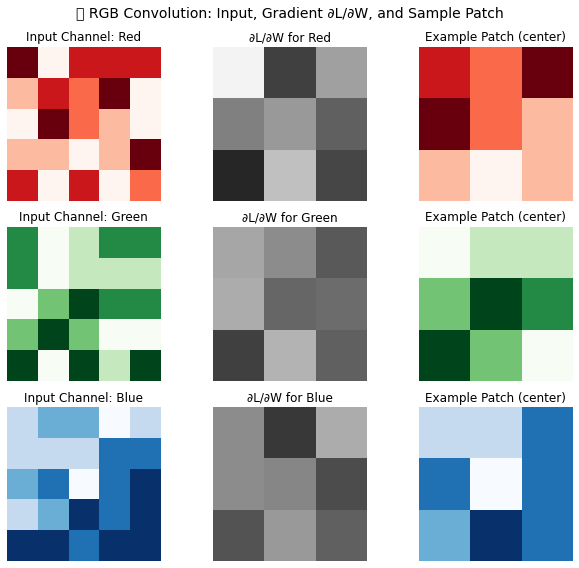

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Sample 3-channel input image (RGB), 5x5
np.random.seed(0)
input_image = np.random.randint(0, 5, (3, 5, 5))  # (C, H, W)

# Simulated gradient from next layer (output of conv), shape (3x3)
dL_dout = np.array([
    [1.0, -1.0,  0.5],
    [0.0,  0.5, -0.5],
    [-1.0, 1.0, -0.5]
])

# Initialize ∂L/∂W (gradients for each 3×3 weight in each channel)
grad_W = np.zeros((3, 3, 3))  # (channels, height, width)

# Accumulate gradients per channel
for i in range(3):  # 0 to H-3
    for j in range(3):  # 0 to W-3
        patch = input_image[:, i:i+3, j:j+3]   # (C, 3, 3)
        delta = dL_dout[i, j]  # scalar
        grad_W += delta * patch  # element-wise contribution

# Visualize
fig, axs = plt.subplots(3, 3, figsize=(9, 8))
channel_names = ['Red', 'Green', 'Blue']

for c in range(3):
    axs[c, 0].imshow(input_image[c], cmap='Reds' if c==0 else 'Greens' if c==1 else 'Blues')
    axs[c, 0].set_title(f"Input Channel: {channel_names[c]}")
    axs[c, 0].axis('off')

    axs[c, 1].imshow(grad_W[c], cmap='gray', vmin=-10, vmax=10)
    axs[c, 1].set_title(f"∂L/∂W for {channel_names[c]}")
    axs[c, 1].axis('off')

    axs[c, 2].imshow(input_image[c, 1:4, 1:4], cmap='Reds' if c==0 else 'Greens' if c==1 else 'Blues')
    axs[c, 2].set_title(f"Example Patch (center)")
    axs[c, 2].axis('off')

fig.suptitle("🔁 RGB Convolution: Input, Gradient ∂L/∂W, and Sample Patch", fontsize=14)
plt.tight_layout()
plt.show()


# do you observe seperate weights getting updated across channels 

In [3]:
# Gradient compute at all centre positions across channel

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Step 1: Create input (3 channels, 5x5 image)
np.random.seed(0)
X = np.random.randint(0, 5, (3, 5, 5))  # (C, H, W)
C, H, W = X.shape

# Step 2: Simulated output gradient from next layer
dL_dout = np.array([
    [1.0, -1.0,  0.5],
    [0.0,  0.5, -0.5],
    [-1.0, 1.0, -0.5]
])  # Shape: (3, 3)

# Step 3: Initialize gradient ∂L/∂W accumulator
grad_W = np.zeros((3, 3, 3))

# Step 4: Set up figure
fig, axs = plt.subplots(3, 3, figsize=(9, 8))
channel_names = ['Red', 'Green', 'Blue']
ims = []

# Step 5: Animate patch-wise updates
for step, (i, j) in enumerate([(i, j) for i in range(H - 2) for j in range(W - 2)]):
    patch = X[:, i:i+3, j:j+3]
    delta = dL_dout[i, j]
    contrib = delta * patch
    grad_W += contrib

    # Collect artists for this frame
    artists = []

    for c in range(3):
        im0 = axs[c, 0].imshow(X[c], cmap='Reds' if c==0 else 'Greens' if c==1 else 'Blues',
                               vmin=0, vmax=5, animated=True)
        axs[c, 0].set_title(f"Input: {channel_names[c]}")
        axs[c, 0].axis('off')

        im1 = axs[c, 1].imshow(grad_W[c], cmap='bwr', vmin=-10, vmax=10, animated=True)
        axs[c, 1].set_title(f"∂L/∂W: {channel_names[c]}")
        axs[c, 1].axis('off')

        im2 = axs[c, 2].imshow(patch[c], cmap='Reds' if c==0 else 'Greens' if c==1 else 'Blues',
                               vmin=0, vmax=5, animated=True)
        axs[c, 2].set_title(f"Patch @ ({i+1},{j+1})")
        axs[c, 2].axis('off')

        artists.extend([im0, im1, im2])

    fig.suptitle(f"Step {step+1}: ∂L/∂W += δ·X | δ={delta:.2f} at output[{i},{j}]", fontsize=14)
    ims.append(artists)

# Step 6: Create and save GIF
ani = animation.ArtistAnimation(fig, ims, interval=1000, blit=True, repeat_delay=1000)
ani.save("rgb_conv_grad_accum.gif", writer='pillow')
plt.close()

print("✅ Animation saved as 'rgb_conv_grad_accum.gif'")


✅ Animation saved as 'rgb_conv_grad_accum.gif'


In [17]:
# Gradient compute at all spatial positions across channel
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches

# Step 1: Create RGB input (3 channels, 5x5)
np.random.seed(0)
X = np.random.randint(0, 5, (3, 5, 5))
C, H, W = X.shape

# Step 2: Simulated output gradient (from next layer)
dL_dout = np.array([
    [1.0, -1.0,  0.5],
    [0.0,  0.5, -0.5],
    [-1.0, 1.0, -0.5]
])  # shape: (3, 3)

# Step 3: Initialize ∂L/∂W accumulator
grad_W = np.zeros((3, 3, 3))

# Step 4: Set up plot
fig, axs = plt.subplots(3, 3, figsize=(9, 8), dpi=100)
channel_names = ['Red', 'Green', 'Blue']
ims = []

# Step 5: Loop through each valid patch
for step, (i, j) in enumerate([(i, j) for i in range(H - 2) for j in range(W - 2)]):
    patch = X[:, i:i+3, j:j+3]
    delta = dL_dout[i, j]
    contrib = delta * patch
    grad_W += contrib

    frame_artists = []

    for c in range(3):
        # Input image
        ax_input = axs[c, 0]
        im0 = ax_input.imshow(X[c], cmap='Reds' if c==0 else 'Greens' if c==1 else 'Blues',
                              vmin=0, vmax=5, animated=True)
        ax_input.set_title(f"Input: {channel_names[c]}")
        ax_input.axis('off')

        # Add red rectangle to show patch
        rect = patches.Rectangle((j - 0.5, i - 0.5), 3, 3, linewidth=2,
                                 edgecolor='red', facecolor='none', animated=True)
        ax_input.add_patch(rect)

        # Accumulated gradient
        ax_grad = axs[c, 1]
        im1 = ax_grad.imshow(grad_W[c], cmap='bwr', vmin=-10, vmax=10, animated=True)
        ax_grad.set_title(f"∂L/∂W: {channel_names[c]}")
        ax_grad.axis('off')

        # The current patch
        ax_patch = axs[c, 2]
        im2 = ax_patch.imshow(patch[c], cmap='Reds' if c==0 else 'Greens' if c==1 else 'Blues',
                              vmin=0, vmax=5, animated=True)
        ax_patch.set_title(f"Patch @ ({i+1},{j+1})")
        ax_patch.axis('off')

        frame_artists.extend([im0, im1, im2, rect])

    fig.suptitle(f"Step {step+1}/9: ∂L/∂W += δ·X | δ={delta:.2f} @ output[{i},{j}]", fontsize=14)
    ims.append(frame_artists)

# Step 6: Save animation
ani = animation.ArtistAnimation(fig, ims, interval=1200, blit=True, repeat_delay=1000)
ani.save("all_patches_grad_accum.gif", writer='pillow')
plt.close()

print("✅ Animation saved as 'all_patches_grad_accum.gif'")


✅ Animation saved as 'all_patches_grad_accum.gif'


In [ ]:
# just checking where i made a mistake, the next cell should work fine

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import matplotlib.patches as patches

# # Create dummy input
# X = np.random.randint(0, 5, (3, 5, 5))  # (C, H, W)
# C, H, W = X.shape
# output = np.zeros((3, 3))

# # Setup figure
# fig, axs = plt.subplots(1, 3, figsize=(10, 3))
# ims = []

# try:
#     i, j = 1, 1  # One patch only
#     patch = X[:, i:i+3, j:j+3]
#     activation = np.sum(patch)
#     output[i, j] = activation

#     frame_artists = []
#     for c in range(3):
#         ax = axs[c]
#         ax.set_title(f"Channel {c}")
#         ax.axis("off")
#         im = ax.imshow(X[c], cmap='gray', vmin=0, vmax=5, animated=True)

#         rect = patches.Rectangle((j - 0.5, i - 0.5), 3, 3,
#                                  linewidth=2, edgecolor='red', facecolor='none', animated=True)
#         ax.add_patch(rect)

#         # Logging
#         print(f"Channel {c}: im = {im}, rect = {rect}")
#         assert im is not None and rect is not None

#         frame_artists.extend([im, rect])

#     ims.append(frame_artists)

#     ani = animation.ArtistAnimation(fig, ims, interval=1000, blit=True, repeat_delay=1000)
#     ani.save("debug_forward.gif", writer='pillow')
#     print("✅ Saved: debug_forward.gif")

# except Exception as e:
#     print("❌ Error during animation:")
#     print(e)


In [19]:
# forward and backward

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches

# Create random input image
np.random.seed(0)
X = np.random.randint(0, 5, (3, 5, 5))
C, H, W = X.shape

# Dummy delta from next layer (simulated output gradients)
dL_dout = np.array([
    [1.0, -1.0,  0.5],
    [0.0,  0.5, -0.5],
    [-1.0, 1.0, -0.5]
])  # shape (3, 3)

# Output activations and gradient accumulator
activation_map = np.zeros((3, 3))
grad_W = np.zeros((3, 3, 3))  # (C, H, W)

# Setup plot
fig, axs = plt.subplots(3, 4, figsize=(12, 9), dpi=100)
channel_names = ['Red', 'Green', 'Blue']
ims = []

# Loop over each patch (same as forward + backward)
for step, (i, j) in enumerate([(i, j) for i in range(H - 2) for j in range(W - 2)]):
    patch = X[:, i:i+3, j:j+3]  # shape (3, 3, 3)
    delta = dL_dout[i, j]
    activation = np.sum(patch)  # dummy forward
    activation_map[i, j] = activation
    grad_W += delta * patch  # backward contribution

    frame_artists = []

    for c in range(3):
        cmap = 'Reds' if c == 0 else 'Greens' if c == 1 else 'Blues'

        # Input image
        im_in = axs[c, 0].imshow(X[c], cmap=cmap, vmin=0, vmax=5, animated=True)
        rect = patches.Rectangle((j - 0.5, i - 0.5), 3, 3,
                                 linewidth=2, edgecolor='red', facecolor='none', animated=True)
        axs[c, 0].add_patch(rect)
        axs[c, 0].set_title(f"Input: {channel_names[c]}")
        axs[c, 0].axis('off')

        # Patch
        im_patch = axs[c, 1].imshow(patch[c], cmap=cmap, vmin=0, vmax=5, animated=True)
        axs[c, 1].set_title(f"Patch ({i+1},{j+1})")
        axs[c, 1].axis('off')

        # Gradients
        im_grad = axs[c, 2].imshow(grad_W[c], cmap='bwr', vmin=-10, vmax=10, animated=True)
        axs[c, 2].set_title(f"∂L/∂W: {channel_names[c]}")
        axs[c, 2].axis('off')

        # Activation Map
        im_out = axs[c, 3].imshow(activation_map, cmap='Blues', vmin=0, vmax=activation_map.max() + 1, animated=True)
        axs[c, 3].set_title("Activation Map")
        axs[c, 3].axis('off')

        frame_artists.extend([im_in, rect, im_patch, im_grad, im_out])

    fig.suptitle(
        f"Step {step+1}/9 | δ = {delta:+.2f} @ Output[{i},{j}] | Forward + Backward",
        fontsize=14
    )
    ims.append(frame_artists)

# Save animation
ani = animation.ArtistAnimation(fig, ims, interval=1000, blit=True, repeat_delay=1000)
ani.save("forward_backward (gradient)_propagation.gif", writer='pillow')
plt.close()
print("✅ Saved: forward_backward(gradient)_propagation.gif")


✅ Saved: forward_backward(gradient)_propagation.gif
